### В этом ноутбуке я начинаю EDA по данным, рассматриваю распределния числовых признаков, доли таргета в разных значениях категориальных признаков, затем рассматриваю корреляции признаков, парные разрезы по таргету, проверяю все ли колонки будут известны в момент предсказания.
В конце ноутбука лежит раздел Findings с моими выводами и идеями для новых признаков.

In [1]:
import pandas as pd
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

def get_engine():
    user = os.environ["POSTGRES_USER"]
    password = os.environ["POSTGRES_PASSWORD"]
    host = os.environ["POSTGRES_HOST"]
    port = os.environ["POSTGRES_PORT"]
    db = os.environ["POSTGRES_DB"]
    return create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}")

engine = get_engine()
sns.set_theme(style="whitegrid")  


In [2]:
pd.read_sql("""SELECT 'customers' AS table_name, COUNT(*) AS rows FROM customers
UNION ALL SELECT 'contracts', COUNT(*) FROM contracts
UNION ALL SELECT 'charges', COUNT(*) FROM charges
UNION ALL SELECT 'churn_labels', COUNT(*) FROM churn_labels
UNION ALL SELECT 'services', COUNT(*) FROM services;""", con=engine)

,table_name,rows
0,customers,7043
1,contracts,7043
2,charges,7043
3,churn_labels,7043
4,services,63387


Количество строк совпадает с исходным датасетом, при переходе в sql бд ничего не потерялось

In [3]:
pd.read_sql("""SELECT COUNT(*) 
FROM charges 
    JOIN contracts ON charges.customer_id = contracts.customer_id 
WHERE contracts.tenure = 0 AND charges.total_charges = 0;""", con=engine)

,count
0,11


Для поддержки единой структуры бд принял решение заменить " " в total_charges на 0 для клиентов у которых tenure = 0 

In [4]:
pd.read_sql("SELECT AVG(churned::int) FROM churn_labels;", engine)

,avg
0,0.26537


Доля таргета ~26.5%, то есть наблюдается небольшой дисбаланс классов, простое предсказание "всегда 0" даст accuracy ~73.5, то есть нужно будет смотреть в сторону сбалансированных метрик - ROC-AUC, PR-AUC, F1, Precision, Recall.

In [5]:
pd.read_sql("""SELECT c.gender, AVG(churned::int) AS churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM customers) AS group_share 
FROM customers AS c 
    JOIN churn_labels ON c.customer_id = churn_labels.customer_id 
GROUP BY c.gender 
ORDER BY churn_rate DESC;""", engine)

,gender,churn_rate,n_customers,group_share
0,Female,0.269209,3488,0.495244
1,Male,0.261603,3555,0.504756


Данные сбалансированы по полу и доли оттока в мужской и женской граппах практически равны и слабо отличаются от общей доли оттока

In [6]:
pd.read_sql("""SELECT c.senior_citizen, AVG(churned::int) AS churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM customers) AS group_share 
FROM customers AS c 
    JOIN churn_labels ON c.customer_id = churn_labels.customer_id 
GROUP BY c.senior_citizen 
ORDER BY churn_rate DESC;""", engine)

,senior_citizen,churn_rate,n_customers,group_share
0,True,0.416813,1142,0.162147
1,False,0.236062,5901,0.837853


В группах пенсионер\не пенсионер есть дисбаланс, пенсионеры составляют ~0.16 от общего числа клтиентов, при этом доля оттока среди них выше средней и больше чем доля оттока у не пенсионеров. 

In [7]:
pd.read_sql("""SELECT c.partner, AVG(churned::int) AS churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM customers) AS group_share 
FROM customers AS c 
    JOIN churn_labels ON c.customer_id = churn_labels.customer_id 
GROUP BY c.partner 
ORDER BY churn_rate DESC;""", engine)

,partner,churn_rate,n_customers,group_share
0,False,0.329580,3641,0.516967
1,True,0.196649,3402,0.483033


Классы людей с парнером и без сбалансированы, при этом среди одиноких людей доля оттока выше

In [8]:
pd.read_sql("""SELECT c.dependents, AVG(churned::int) AS churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM customers) AS group_share 
FROM customers AS c 
    JOIN churn_labels ON c.customer_id = churn_labels.customer_id 
GROUP BY c.dependents 
ORDER BY churn_rate DESC;""", engine)

,dependents,churn_rate,n_customers,group_share
0,False,0.312791,4933,0.700412
1,True,0.154502,2110,0.299588


Классы людей с иждивенцами\без имеют перекос, при этом доля оттока среди людей без иждивенцев в 2 раза превышает долю оттока среди людей опекающих кого-либо

In [9]:
pd.read_sql("""SELECT c.contract, AVG(churned::int) as churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM contracts) as group_shape
FROM contracts as c JOIN churn_labels ON c.customer_id = churn_labels.customer_id
GROUP BY c.contract
ORDER BY churn_rate DESC;""", engine)

,contract,churn_rate,n_customers,group_shape
0,Month-to-month,0.427097,3875,0.550192
1,One year,0.112695,1473,0.209144
2,Two year,0.028319,1695,0.240664


Наибольшей группой являются клиенты с контрактом на срок меньше года и среди них наибольшая доля оттока, однако с ростом срока контракта эта доля уменьшается и для 2-х летних контрактов она составляет менее 3%.

In [10]:
tenure = pd.read_sql("""SELECT c.tenure, AVG(churned::int) as churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM contracts) as group_shape
FROM contracts as c JOIN churn_labels ON c.customer_id = churn_labels.customer_id
GROUP BY c.tenure
ORDER BY c.tenure ASC;""", engine)
tenure.head()

,tenure,churn_rate,n_customers,group_shape
0,0,0.000000,11,0.001562
1,1,0.619902,613,0.087037
2,2,0.516807,238,0.033792
3,3,0.470000,200,0.028397
4,4,0.471591,176,0.024989


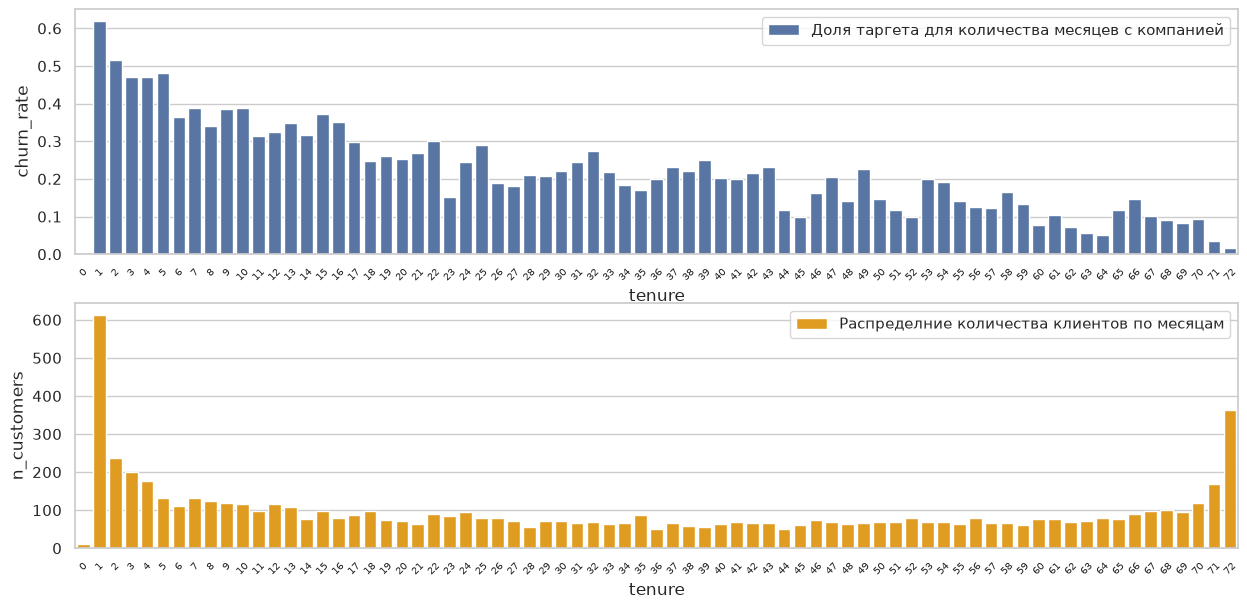

In [11]:
f, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 7))
sns.barplot(x='tenure', y='churn_rate', data=tenure, label='Доля таргета для количества месяцев с компанией', ax=ax[0])
sns.barplot(x='tenure', y='n_customers', data=tenure, label='Распределние количества клиентов по месяцам', ax=ax[1], color='orange')
ax[0].tick_params(axis='x', rotation=45, labelsize=7)
ax[1].tick_params(axis='x', rotation=45, labelsize=7)

Из графика видно, есть некоторый тренд - чем дольше человек с компнией, тем реже он уходит. Сразу видно связь с тем, что чем более долгий контракт у клиента тем реже он уходит (3% у 2х годичных контрактов). При этом для клиентов которые только пришли таргет равен нулю, что справедливо, ведь клиенты которым пока что даже не выставили счет не уходят.

In [12]:
pd.read_sql("""SELECT c.paperless_billing, AVG(churned::int) as churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM contracts) as group_shape
FROM contracts as c JOIN churn_labels ON c.customer_id = churn_labels.customer_id
GROUP BY c.paperless_billing
ORDER BY churn_rate DESC;""", engine)

,paperless_billing,churn_rate,n_customers,group_shape
0,True,0.335651,4171,0.592219
1,False,0.163301,2872,0.407781


Доля людей получающих бумажные счета меньше доли остальных, однако они (получающие бумаженые счета) уходят в 2 раза реже

In [13]:
pd.read_sql("""SELECT c.payment_method, AVG(churned::int) as churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric / (SELECT COUNT(*) FROM contracts) as group_shape
FROM contracts as c JOIN churn_labels ON c.customer_id = churn_labels.customer_id
GROUP BY c.payment_method
ORDER BY churn_rate DESC;""", engine)

,payment_method,churn_rate,n_customers,group_shape
0,Electronic check,0.452854,2365,0.335794
1,Mailed check,0.191067,1612,0.228880
2,Bank transfer (automatic),0.167098,1544,0.219225
3,Credit card (automatic),0.152431,1522,0.216101


Из данных о методе платежа видно, что наибольшая доля оттока среди тех, кто пользуется электронным чеком, при этом наименьшая - в 3 раза наибольшей - среди клиентов с автоматическим платежом кредитной картой

In [40]:
s_types = pd.read_sql("""SELECT s.service_type, s.service_status, AVG(churned::int) as churn_rate, COUNT(*) AS n_customers, COUNT(*)::numeric /
(SELECT COUNT(*) FROM customers) 
AS group_shape
FROM services AS s JOIN churn_labels ON s.customer_id = churn_labels.customer_id
GROUP BY s.service_type, s.service_status
ORDER BY churn_rate DESC;""", engine)

Существует категория No internet service для интернет-услуг у людей, которые не подключали себе интернет, нужно подумать слить ли ее в общую категорию с No или просто удалить эти категории, т.к. эти группы явно совпадают с группой людей у которых Internet - No

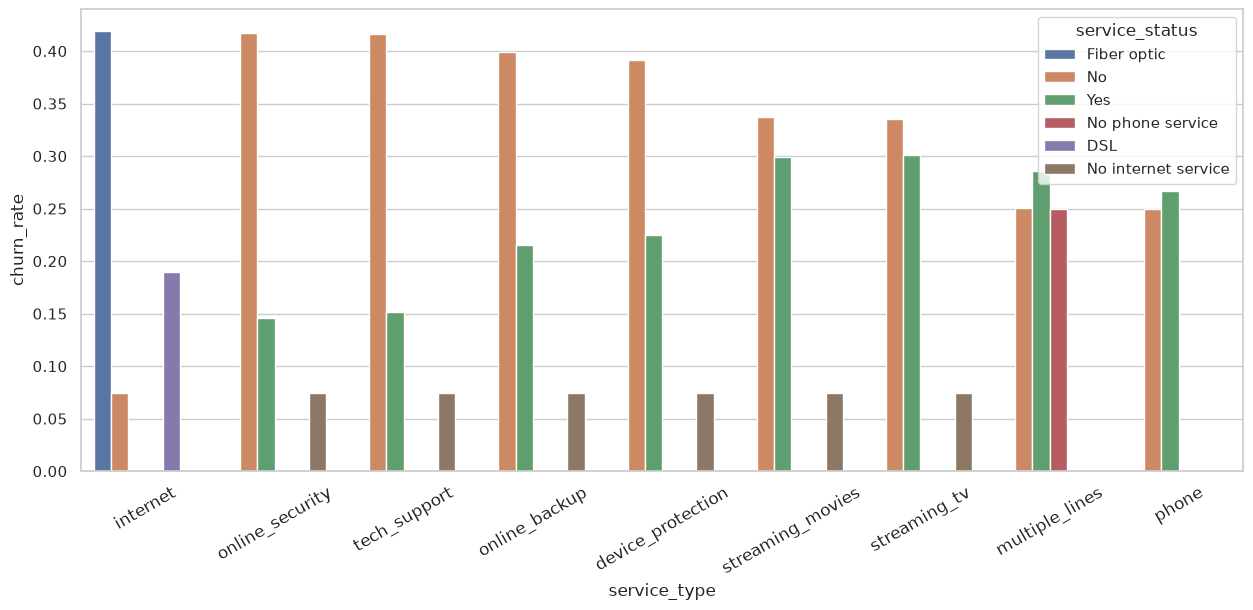

In [15]:
f, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x='service_type', y='churn_rate', data=s_types, hue='service_status', errorbar=None)
ax.tick_params(rotation=30, axis='x', labelsize=12)

Из графика видно, что при отстутвии некоторых услуг (tech_support, online_security и т.д.) клиенты уходят гораздо чаще

In [16]:
def hist_and_box(df:pd.DataFrame, col_name:str):
    f, ax = plt.subplots(ncols=2, nrows=1, figsize=(16,7))
    sns.histplot(df, x=col_name, hue='churned', element="step", stat="density", common_norm=False, ax=ax[0])
    ax[0].set_title(f'Форма распределения {col_name} в разрезе таргета')
    sns.boxplot(df, x='churned', y=col_name, ax=ax[1], color='orange')
    ax[1].set_title(f'Ящик с усами для {col_name} в разрезе таргета')
    plt.show()

#функция для отрисовки гистограммы и ящика с усами

In [17]:
df = pd.read_sql(""" SELECT l.churned, co.tenure, c.monthly_charges, c.total_charges 
FROM contracts AS co 
    JOIN charges AS c ON co.customer_id = c.customer_id 
    JOIN churn_labels AS l ON l.customer_id = co.customer_id;""", engine)

In [18]:
pd.read_sql("""SELECT l.churned, COUNT(*) AS n, MIN(c.tenure) AS min, PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY c.tenure) AS q25,
PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY c.tenure) AS med, PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY c.tenure) AS q75,
MAX(c.tenure) AS max, AVG(tenure) AS mean FROM churn_labels as l JOIN contracts AS c ON l.customer_id = c.customer_id
GROUP BY l.churned ORDER BY l.churned DESC;""", engine)

,churned,n,min,q25,med,q75,max,mean
0,True,1869,1,2.0,10.0,29.0,72,17.979133
1,False,5174,0,15.0,38.0,61.0,72,37.569965


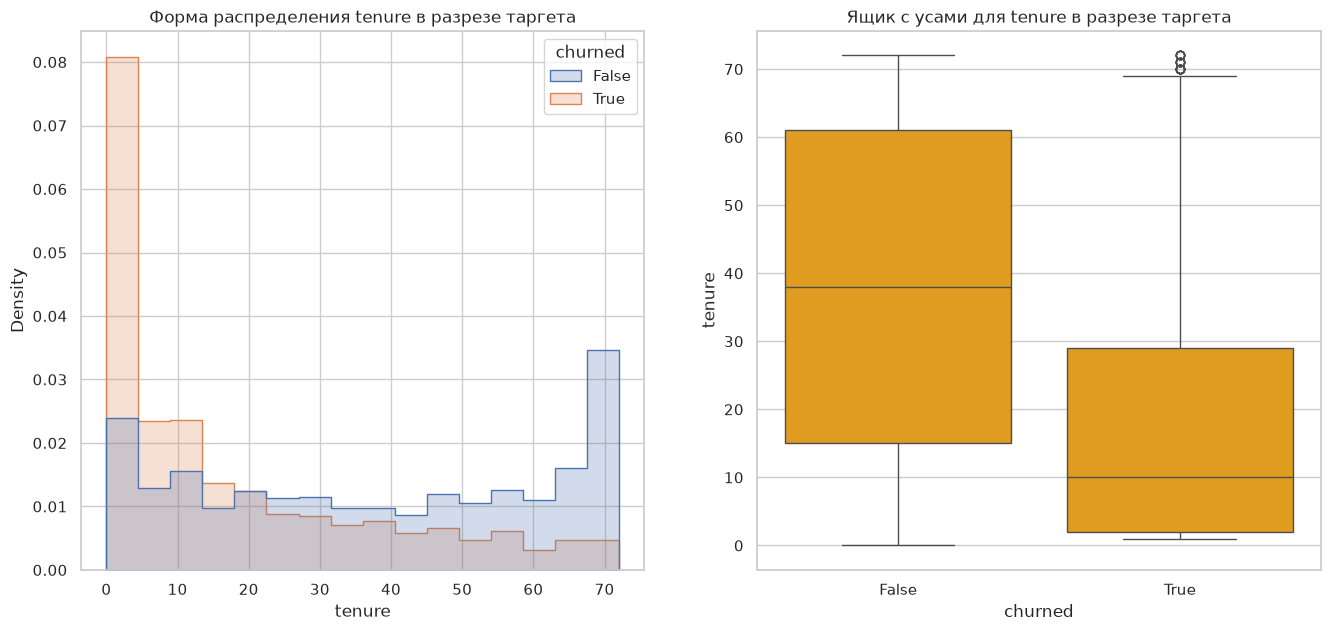

In [19]:
hist_and_box(df=df, col_name='tenure')

Из данных видно, что распределение по tenure для true скошено влево, то есть клиенты больше уходят при маленьком сроке, а для false скошено вправо, то есть если клиент уже долго с компанией, то он остается.

In [20]:
pd.read_sql("""SELECT l.churned, COUNT(*) AS n, MIN(c.monthly_charges) AS min, PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY c.monthly_charges) AS q25,
PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY c.monthly_charges) AS med, PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY c.monthly_charges) AS q75,
MAX(c.monthly_charges) AS max, AVG(monthly_charges) AS mean FROM churn_labels as l JOIN charges AS c ON l.customer_id = c.customer_id
GROUP BY l.churned ORDER BY l.churned DESC;""", engine)

,churned,n,min,q25,med,q75,max,mean
0,True,1869,18.85,56.15,79.650,94.2,118.35,74.441332
1,False,5174,18.25,25.10,64.425,88.4,118.75,61.265124


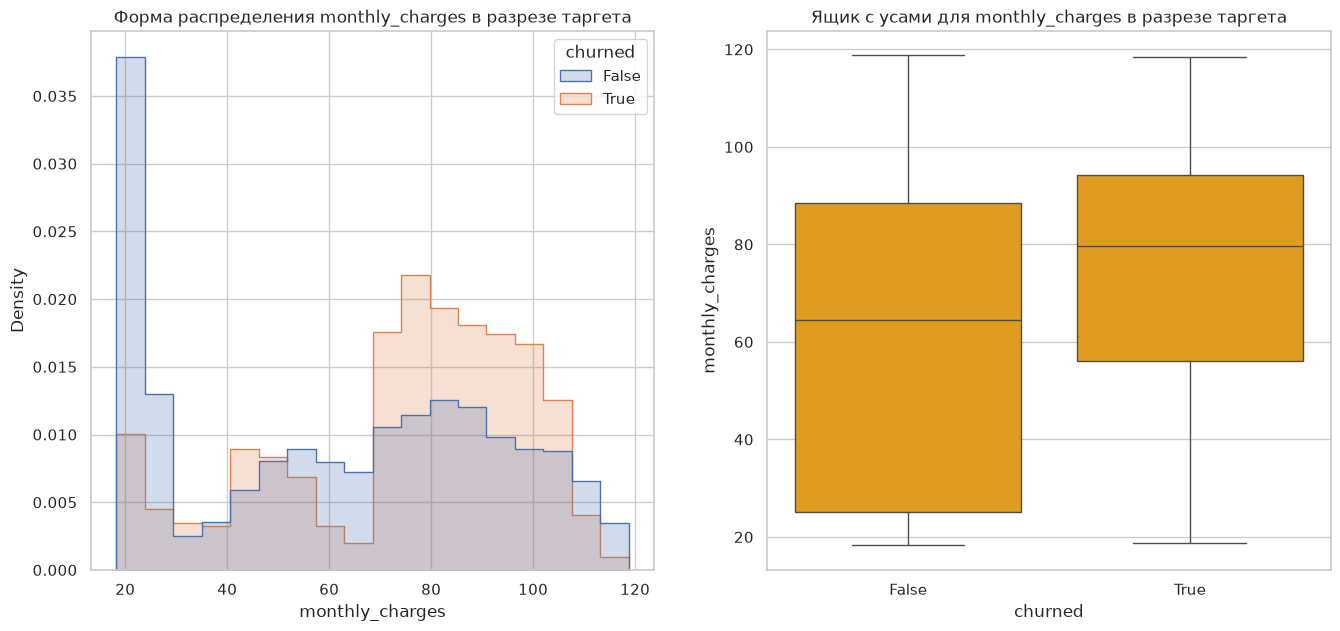

In [21]:
hist_and_box(df=df, col_name='monthly_charges')

Из данных видно, что медиана месячного платежа уходящих клиентов чуть выше, и в целом они сосредоточены в диапазоне от 70 до 110, тогда как при низком платеже клиенты в основном остаются, при этом при высоком платеже (более 110), клиенты также сокрее остаются

In [22]:
pd.read_sql("""SELECT l.churned, COUNT(*) AS n, MIN(c.total_charges) AS min, PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY c.total_charges) AS q25,
PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY c.total_charges) AS med, PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY c.total_charges) AS q75,
MAX(c.total_charges) AS max, AVG(total_charges) AS mean FROM churn_labels as l JOIN charges AS c ON l.customer_id = c.customer_id
GROUP BY l.churned ORDER BY l.churned DESC;""", engine)

,churned,n,min,q25,med,q75,max,mean
0,True,1869,18.85,134.5,703.550,2331.30,8684.80,1531.796094
1,False,5174,0.00,572.9,1679.525,4262.85,8672.45,2549.911442


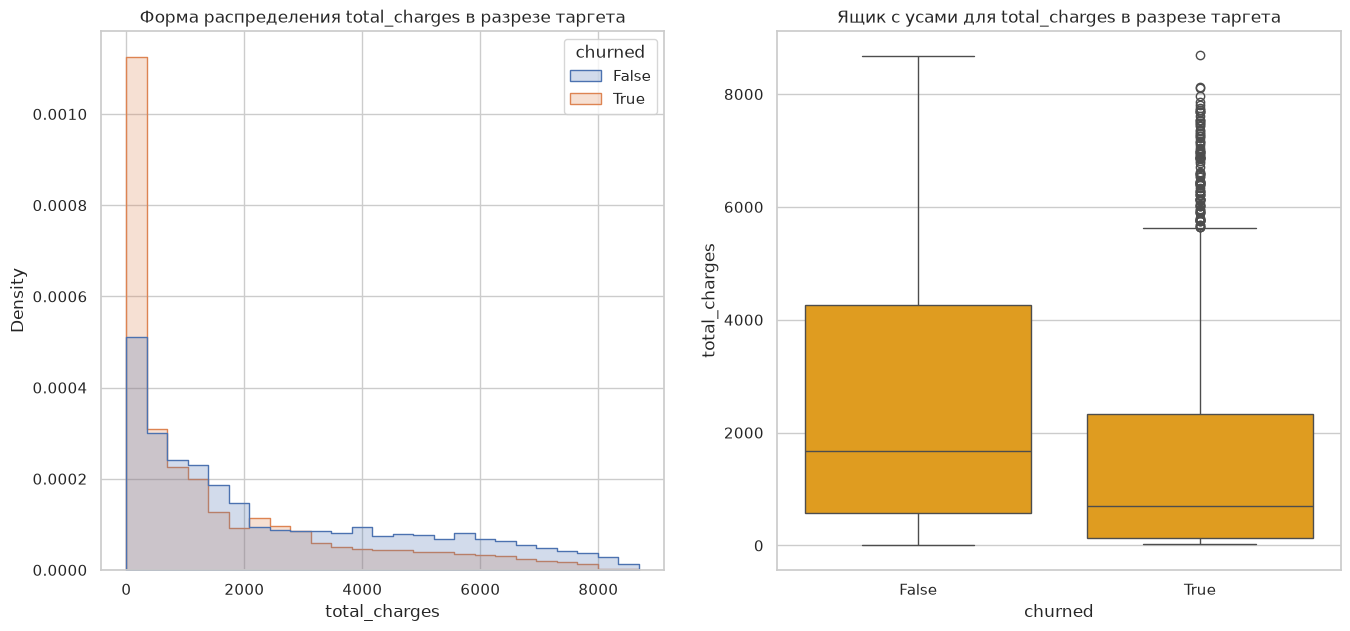

In [23]:
hist_and_box(df=df, col_name='total_charges')

Отсюда видно, что в основном уходят клиенты с маленким общим счетом, но это скорее всего связано с тем, что уходят клиенты с маленьким tenure, а для маленького времени пользования общий счет за услуги также явно будет небольшим, т.е. стоит подумать об удалении этого признака

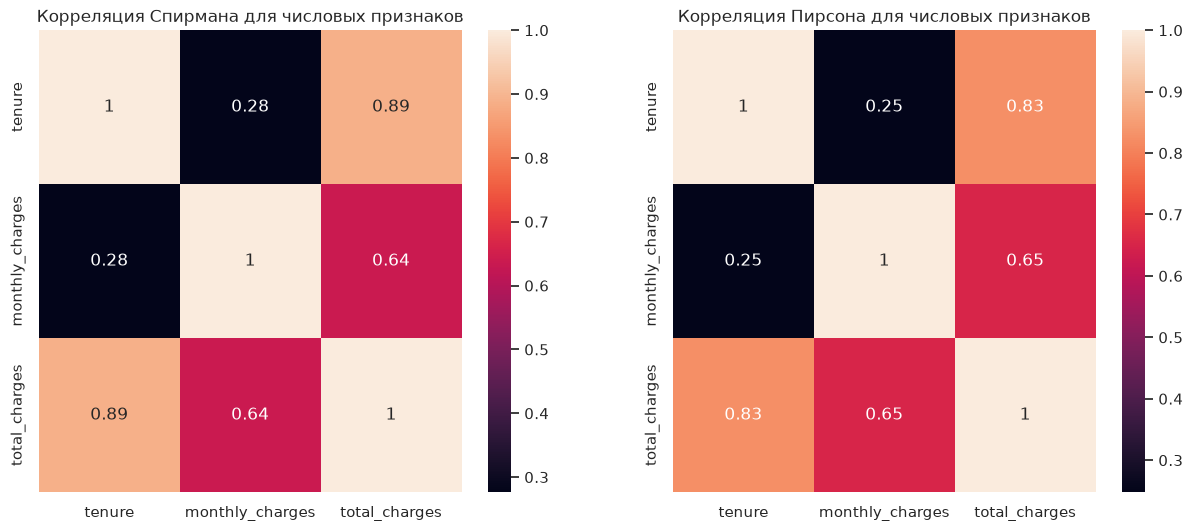

In [24]:
df = pd.read_sql("""SELECT co.tenure, ch.monthly_charges, ch.total_charges 
FROM contracts AS co JOIN charges AS ch ON co.customer_id = ch.customer_id""", engine)
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
sns.heatmap(df.corr(method='spearman'), annot=True, ax=ax[0])
sns.heatmap(df.corr(method='pearson'), annot=True, ax=ax[1])
ax[0].set_title('Корреляция Спирмана для числовых признаков')
ax[1].set_title('Корреляция Пирсона для числовых признаков')
plt.show()

Из хитмапа видно, что обе корреляции говорят о сильной скореллированности признаков total_charges и tenure. Это весьма очевидно, так как можно сказать что total_charges = monthly_charges * tenure. В целом бустинги, которые я планирую использовать не восприимчивы к таким зависимостям как регрессии, но признак все равно стоит позже выкинуть чтобы не тащить бесполезную информацию.

In [25]:
def plot_heatmap(idx, col, df, target):
    f, ax = plt.subplots(figsize=(10, 4))
    df1 = pd.pivot_table(df, index=idx, columns=col, values=target)
    df2 = pd.pivot_table(df, index=idx, columns=col, values='n')
    annot=df1.copy().astype(object)
    for i in df1.index:
        for c in df2.columns:
            annot.loc[i, c] = f"{df1.loc[i, c]:.0%}\n(n={df2.loc[i, c]})"
    sns.heatmap(data=df1, annot=annot, ax=ax, fmt='')
    ax.set_title(f"Доля {target} в разрезе {idx}&{col}")
    ax.tick_params(rotation=20, axis='x')
    plt.show()

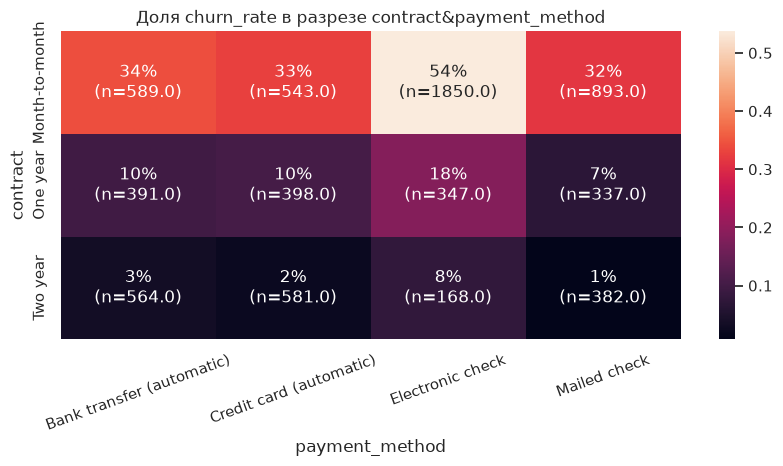

In [26]:
df = pd.read_sql("""SELECT co.contract, co.payment_method, AVG(l.churned::int) as churn_rate, COUNT(*) AS n
FROM contracts AS co JOIN churn_labels AS l ON co.customer_id = l.customer_id
GROUP BY co.contract, co.payment_method""", engine)
plot_heatmap('contract', 'payment_method', df, 'churn_rate')

Очень высокая доля оттока у сочетания electronic check & month-to-month

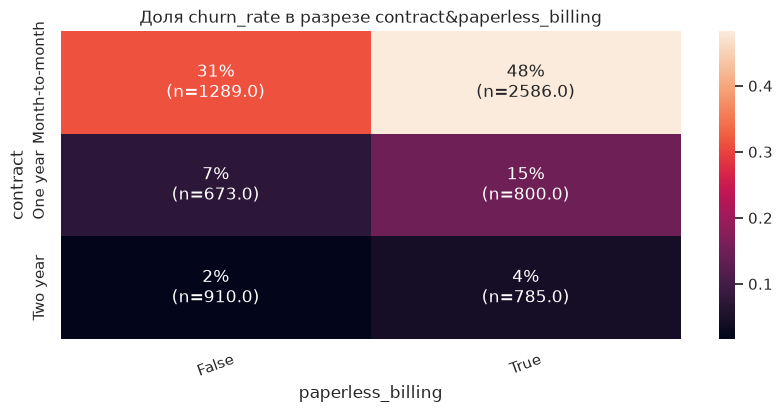

In [27]:
df = pd.read_sql("""SELECT co.contract, co.paperless_billing, AVG(l.churned::int) as churn_rate, COUNT(*) AS n
FROM contracts AS co JOIN churn_labels AS l ON co.customer_id = l.customer_id
GROUP BY co.contract, co.paperless_billing""", engine)
plot_heatmap('contract', 'paperless_billing', df, 'churn_rate')

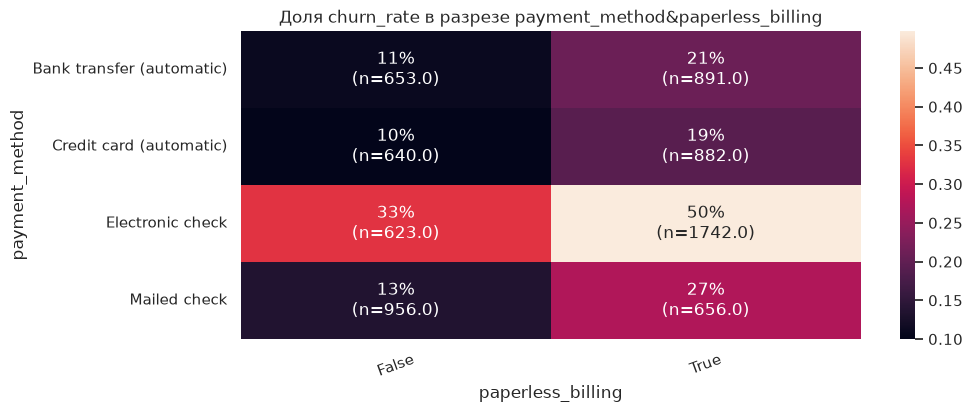

In [28]:
df = pd.read_sql("""SELECT co.payment_method, co.paperless_billing, AVG(l.churned::int) as churn_rate, COUNT(*) AS n
FROM contracts AS co JOIN churn_labels AS l ON co.customer_id = l.customer_id
GROUP BY co.payment_method, co.paperless_billing""", engine)
plot_heatmap('payment_method', 'paperless_billing', df, 'churn_rate')

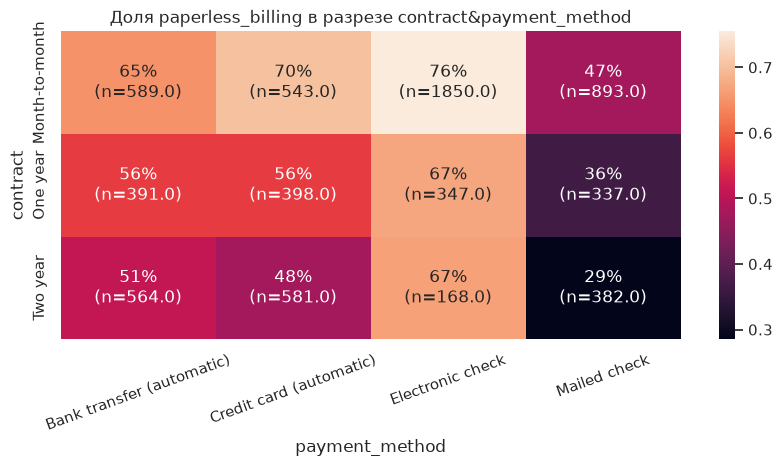

In [29]:
df = pd.read_sql("""SELECT contract, payment_method, AVG(paperless_billing::int) as paperless_billing, COUNT(*) AS n
FROM contracts
GROUP BY 1, 2""", engine)
plot_heatmap('contract', 'payment_method', df, 'paperless_billing')

Исходя из графиков видно, что максимальный отток у пользователей с профилем electronic_check + month-to-month + paperless_billing, поэтому можно рассмотреть создание отдельного флага для пользователей с таким комплектом.

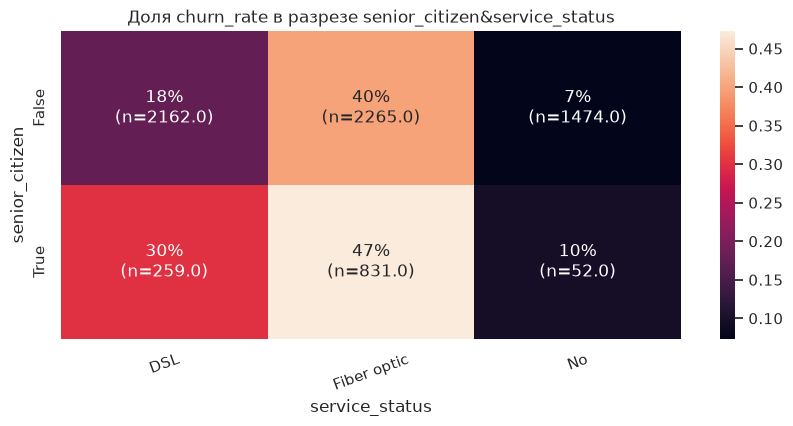

In [30]:
df = pd.read_sql("""SELECT c.senior_citizen, s.service_status, AVG(l.churned::int) AS churn_rate, COUNT(*) AS n
FROM customers AS c JOIN services AS s on c.customer_id = s.customer_id
JOIN churn_labels AS l on l.customer_id = c.customer_id
WHERE s.service_type = 'internet'
GROUP BY c.senior_citizen, s.service_status""", engine)
plot_heatmap('senior_citizen', 'service_status', df, 'churn_rate')
#pd.pivot_table(data=df, columns='senior_citizen', index='service_status', values='churn_rate')

Отсюда видно, что наибольший отток сосредоточен среди клентов с оптоволоконным интернетом, при этом он выше всего для пенсионеров + оптоволокно.

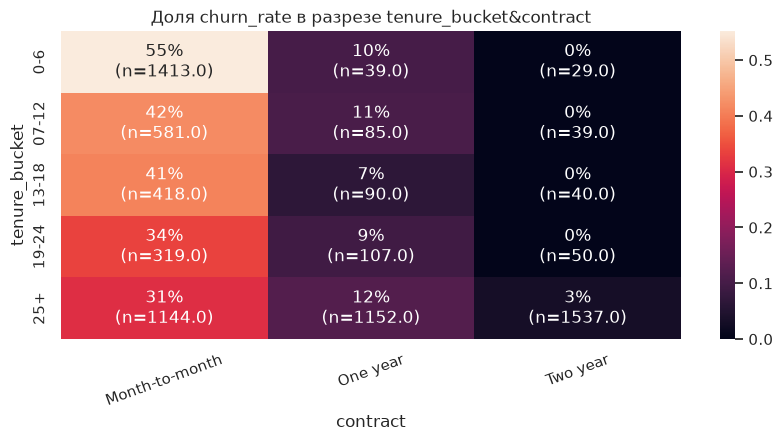

In [31]:
df = pd.read_sql("""SELECT CASE
WHEN tenure <= 6 THEN '0-6'
WHEN tenure <= 12 THEN '07-12'
WHEN tenure <= 18 THEN '13-18'
WHEN tenure <= 24 THEN '19-24'
ELSE '25+' END AS tenure_bucket,
co.contract, AVG(l.churned::int) AS churn_rate, COUNT(*) AS n
FROM contracts AS co JOIN churn_labels AS l ON l.customer_id = co.customer_id
GROUP BY 1, 2""", engine)
plot_heatmap('tenure_bucket', 'contract', df, 'churn_rate')

Этот график говорит о том же, что клиенты с месячным контрактом и небольших сроком в компании гораздно сильнее склонны к уходу

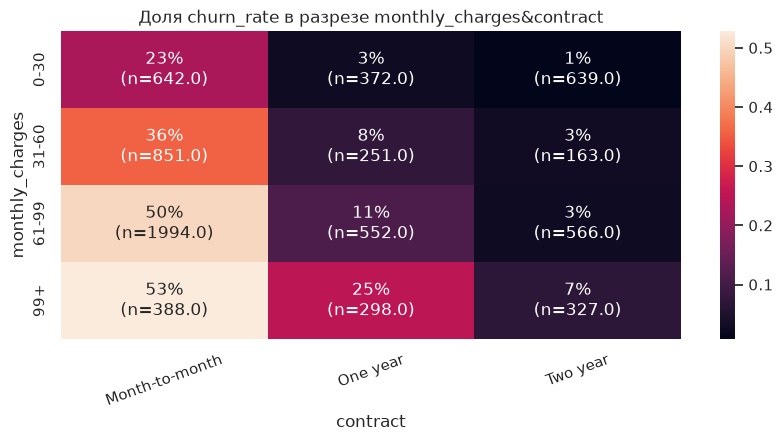

In [39]:
df = pd.read_sql("""SELECT co.contract, 
CASE 
WHEN ch.monthly_charges <= 30 THEN '0-30'
WHEN ch.monthly_charges <= 60 THEN '31-60'
WHEN ch.monthly_charges <= 99 THEN '61-99'
ELSE '99+' END AS monthly_charges, AVG(l.churned::int) AS churn_rate, COUNT(*) AS n
FROM contracts AS co JOIN charges AS ch ON co.customer_id = ch.customer_id
JOIN churn_labels AS l ON l.customer_id = co.customer_id
GROUP BY 1, 2""", engine)
plot_heatmap('monthly_charges', 'contract', df, 'churn_rate')

Из этого графика также видно, что чем больше месячный платеж, тем активнее уходят клиенты с любым типом контракта, при этом на месячных контрактах ситуация наиболее катастрофична

## Анализ колонок на утечки

 - customerID - уникальный идентификатор, не подается модели на вход
 - gender - пол, известен в момент предсказания, нет утечки
 - SeniorCitizen - флаг является ли клиент пенсионером, нет утечки
 - Partner - есть ли у клиента партнер, нет утечки,
 - Dependents - есть ли у клиента иждивенцы, нет утечки
 - tenure - срок с компанией, нет утечки
 - PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV, StreamingMovies - флаги услуг, нет утечки
 - Contract - тип контракта, нет утечки
 - PaperlessBilling - флаг электронная ли квитанция, нет утечки
 - PaymentMethod - тип платежа, нет утечки
 - MonthlyCharges - ужемесячный платеж, нет утечки
 - TotalCharges - сумма платежей за все время, нет утечки,
 - Churn - таргет - ушел ли клиент.

## Findings

В результате EDA было выяснено следующее:
- Доля таргета ~26.5%, что говорит о небольшом дисбалансе классов и невалидности accuracy.
- Данные в разрезе таргета и количества сбалансированы по полу.
- Среди пенсионеров доля оттока выше.
- Среди одиноких доля оттока выше.
- Среди людей без иждивенцев доля оттока выше.
- Отток среди людей с месячным контрактом в ~4 раза выше чем с годовым и в ~14 раз выше чем с двухлетним.
- С увеличением длительности нахождения в компании вероятность ухода уменьшается.
- Получающие электронные квитанции уходят в 2 раза чаще чем получающие бумажные.
- Электронный чек является наиболее опасным с очки зрения ухода средством платежа.
- Существует группа защитных услухм (tech_support, online_protection и т.д.) при подключении которых клиенты уходят в 2 раза реже.
- Уходят в основном клиенты с низким total_charges, но выяснилось что признак сильно скореллирован с tenure и его надо удалить.
- Очень высокий отток (~50%) у пользователей с профилем electronic_check + month-to-month + paperless_billing.
- Наибольшая доля оттока среди клентов с месячным контрактом и ежемесячным платежом > 60.
